# Job Shop and Open Shop Scheduling
**Date:** 16/01/2026 

#### **Course:** Analytics Decision Support Systems
#### Master in Data Science and Engineering - FEUP

#### **Group:**

202206098 - Beatriz Sonnemberg
\
202208293 - Beatriz Moreira
\
202207879 - Marta Costa


### **1. Problem Description and Matematical Formulation**


#### **1.1. Problem Description**

The scheduling problem consists of a set of jobs $\mathcal{J} = \{0, \dots, n-1\}$ that must be processed on a set of machines $\mathcal{M} = \{0, \dots, m-1\}$. Each job $i \in \mathcal{J}$ is composed of a set of operations indexed by $k \in O_i$, where $O_i = \{0, \dots, n_i-1\}$. Each operation $(i, k)$ has a fixed processing time $p_{ik}$ and must be executed on a specific machine $m_{ik} \in \mathcal{M}$. Each machine can process at most one operation at a time, and preemption (interrupting an operation) is not allowed.

We distinguish between two variants of the problem:
1. **Job Shop Scheduling (JSP):** Each job $i$ has a strict technological sequence. Operation $(i, k)$ must be completed before $(i, k+1)$ can begin.
2. **Open Shop Scheduling (OSP):** There is no fixed sequence for the operations within a job. The operations of job $i$ can be processed in any order, but they still cannot overlap (a job can only be on one machine at a time).

The objective for both variants is to minimize the **makespan** ($C_{max}$), which is the total time required to complete all operations.

#### **1.2. Mathematical Formulation**

#### Parameters
* $\mathcal{J}$: Set of jobs.
* $\mathcal{M}$: Set of machines.
* $O_i$: Ordered set of operations for job $i \in \mathcal{J}$, where $O_i = \{0, 1, \dots, n_i-1\}$.
* $p_{ik}$: Processing time of operation $k \in O_i$ of job $i$.
* $m_{ik} \in \mathcal{M}$: Machine required for operation $k$ of job $i$.
* $M$: A sufficiently large positive constant (Big-M).

#### Decision Variables
* $s_{ik} \in \mathbb{R}_+$: Continuous start time of operation $k$ of job $i$.
* $C_{max} \in \mathbb{R}_+$: Continuous variable for the maximum completion time (Makespan).
* $y_{ik, jl} \in \{0, 1\}$: Binary variable; 1 if operation $O_{ik}$ precedes $O_{jl}$ on the same machine, 0 otherwise.
* $z_{ik, iq} \in \{0, 1\}$: Binary variable; 1 if operation $O_{ik}$ precedes $O_{iq}$ within the same job $i$, 0 otherwise (Open Shop only).

#### Objective Function
$$\min \quad C_{max}$$

#### Constraints

**1. Makespan Definition:**
Ensures $C_{max}$ is at least the completion time of every operation:
$$C_{max} \geq s_{ik} + p_{ik} \quad \forall i \in \mathcal{J}, k \in O_i \quad (1)$$

**2. Machine Disjunctive Constraints (No machine overlap):**
For every pair of operations $(O_{ik}, O_{jl})$ such that $m_{ik} = m_{jl}$ and $(i,k) \neq (j,l)$:
$$s_{ik} + p_{ik} \leq s_{jl} + M(1 - y_{ik, jl}) \quad (2)$$
$$s_{jl} + p_{jl} \leq s_{ik} + M(y_{ik, jl}) \quad (3)$$

**3. Job Constraints - Variant A: Job Shop (Strict technological sequence):**
$$s_{i, k+1} \geq s_{ik} + p_{ik} \quad \forall i \in \mathcal{J}, k \in \{0, \dots, |O_i|-2\} \quad (4)$$

**4. Job Constraints - Variant B: Open Shop (No predefined sequence, no overlap):**
For every pair of operations $(O_{ik}, O_{iq})$ within the same job $i$ where $k < q$:
$$s_{ik} + p_{ik} \leq s_{iq} + M(1 - z_{ik, iq}) \quad (5)$$
$$s_{iq} + p_{iq} \leq s_{ik} + M(z_{ik, iq}) \quad (6)$$

**5. Variable Domains:**
$$s_{ik} \geq 0, \quad C_{max} \geq 0 \quad (7)$$
$$y_{ik, jl} \in \{0, 1\}, \quad z_{ik, iq} \in \{0, 1\} \quad (8)$$

### **2. Methodology and Solution Approaches**

To solve the scheduling problems defined above, this project implements and compares two distinct paradigms in Mathematical Optimization:

1. **Mixed-Integer Programming (MIP):** Implemented using the `PuLP` library. This approach follows the classic disjunctive formulation using Big-M constraints. It provides a precise mathematical framework but is known to suffer from scalability issues in scheduling problems due to the high number of binary variables required to model disjunctions.

2. **Constraint Programming (CP):** Implemented using Google's `OR-Tools` (CP-SAT solver). This approach utilizes **Interval Variables** and high-level global constraints, specifically the `NoOverlap` constraint. Unlike MIP, which relies on linear inequalities and Big-M, CP focuses on domain reduction and specialized interval variables, offering a more robust alternative for handling machine and job occupancy.

By implementing both, we aim to benchmark their performance across different instance sizes and problem types (Job Shop vs. Open Shop).

### **3. Environment Setup**

In [14]:
# Dependencies
import time
import pulp
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import List, Dict, Tuple
from ortools.sat.python import cp_model


In [15]:
# Set up paths

# Directory for Taillard instances
DATA_DIR = Path("instances")   

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Directory does not exist: {DATA_DIR}")

# Directory for results
Path("results").mkdir(parents=True, exist_ok=True)
RESULTS_DIR = Path("results")


### **4. Data Modeling and Parsing**

This section defines the data structures to handle scheduling instances and includes parsers for the Taillard benchmark library and hardcoded validation cases.

#### **4.1. JSP Instance Representation**

In [16]:
#JSP Instance Representation
class JSPInstance:
    """Data structure for a Job Shop Problem instance."""
    
    def __init__(self, name: str, num_jobs: int, num_machines: int,
                 jobs: List[List[Tuple[int, int]]]):
        self.name = name
        self.num_jobs = num_jobs
        self.num_machines = num_machines
        self.jobs = jobs
        
    def get_processing_times_matrix(self):
        return [[op[1] for op in job] for job in self.jobs]
    
    def get_machine_sequence_matrix(self):
        return [[op[0] for op in job] for job in self.jobs]
    
    def __repr__(self):
        return f"JSPInstance({self.name}, {self.num_jobs}x{self.num_machines})"


#### **4.2. Hardcoded Test Instances**


In [17]:
# Generate an hardcoded instance for validation and visualization
def create_hardcoded_instances() -> Dict[str, JSPInstance]:
    simple_3x3 = JSPInstance(
        "simple_3x3", 3, 3,
        [   [(0,3),(1,2),(2,2)],
            [(0,2),(2,1),(1,4)],
            [(1,4),(2,3),(0,3)]
        ])
    
    ft06 = JSPInstance("ft06", 6, 6,
        [   [(2,1),(0,3),(1,6),(3,7),(5,3),(4,6)],
            [(1,8),(2,5),(4,10),(5,10),(0,10),(3,4)],
            [(2,5),(3,4),(5,8),(0,9),(1,1),(4,7)],
            [(1,5),(0,5),(2,5),(3,3),(4,8),(5,9)],
            [(2,9),(1,3),(4,5),(5,4),(0,3),(3,1)],
            [(1,3),(3,3),(5,9),(0,10),(4,4),(2,1)]
        ])
    
    return {"simple_3x3": simple_3x3, "ft06": ft06}

In [18]:
# Create instances
hardcoded_instances = create_hardcoded_instances()
print(hardcoded_instances)

{'simple_3x3': JSPInstance(simple_3x3, 3x3), 'ft06': JSPInstance(ft06, 6x6)}


### **4.3. Taillard Instances**

In [19]:
# Taillard instance parser 

def parse_taillard_instance(text: str, name: str) -> JSPInstance:
    """Parses Taillard raw text into a JSPInstance object."""

    lines = [l.strip() for l in text.splitlines() if l.strip()]
    num_jobs, num_machines = map(int, lines[0].split())

    jobs = []
    for i in range(1, num_jobs + 1):
        values = list(map(int, lines[i].split()))
        job = [(values[k], values[k+1]) for k in range(0, len(values), 2)]
        jobs.append(job)

    return JSPInstance(name, num_jobs, num_machines, jobs)


In [20]:
# Taillard instance loader
def load_all_taillard_instances(path: Path):
    instances = {}
    for file in sorted(path.glob("*.txt")):
        with open(file, "r") as f:
            instances[file.stem] = parse_taillard_instance(f.read(), file.stem)
    return instances


In [21]:
# Load Taillard instances
taillard_instances = load_all_taillard_instances(DATA_DIR)
print(f"Loaded {len(taillard_instances)} Taillard instances:")
for name, inst in taillard_instances.items():
    print(f"  {name}: {inst.num_jobs}x{inst.num_machines}")

Loaded 80 Taillard instances:
  ta01: 15x15
  ta02: 15x15
  ta03: 15x15
  ta04: 15x15
  ta05: 15x15
  ta06: 15x15
  ta07: 15x15
  ta08: 15x15
  ta09: 15x15
  ta10: 15x15
  ta11: 20x15
  ta12: 20x15
  ta13: 20x15
  ta14: 20x15
  ta15: 20x15
  ta16: 20x15
  ta17: 20x15
  ta18: 20x15
  ta19: 20x15
  ta20: 20x15
  ta21: 20x20
  ta22: 20x20
  ta23: 20x20
  ta24: 20x20
  ta25: 20x20
  ta26: 20x20
  ta27: 20x20
  ta28: 20x20
  ta29: 20x20
  ta30: 20x20
  ta31: 30x15
  ta32: 30x15
  ta33: 30x15
  ta34: 30x15
  ta35: 30x15
  ta36: 30x15
  ta37: 30x15
  ta38: 30x15
  ta39: 30x15
  ta40: 30x15
  ta41: 30x20
  ta42: 30x20
  ta43: 30x20
  ta44: 30x20
  ta45: 30x20
  ta46: 30x20
  ta47: 30x20
  ta48: 30x20
  ta49: 30x20
  ta50: 30x20
  ta51: 50x15
  ta52: 50x15
  ta53: 50x15
  ta54: 50x15
  ta55: 50x15
  ta56: 50x15
  ta57: 50x15
  ta58: 50x15
  ta59: 50x15
  ta60: 50x15
  ta61: 50x20
  ta62: 50x20
  ta63: 50x20
  ta64: 50x20
  ta65: 50x20
  ta66: 50x20
  ta67: 50x20
  ta68: 50x20
  ta69: 50x20
  ta

### **5. Model Formulations**

The MIP and CP Models solve both **Job Shop** and **Open Shop** scheduling problems. The difference between the two is handled by **job-specific constraints**.

### **5.1. MIP Implementation (Job Shop & Open Shop)**

#### **Overview**
- Objective: **Minimize makespan** (`Cmax`)
- Variables:
  - Continuous start times for all operations
  - Binary variables for sequencing decisions
- Job constraints:
  - **Job Shop:** operations follow a fixed sequence
  - **Open Shop:** operations can be scheduled in any order but cannot overlap

#### **Machine Constraints**
- Disjunctive constraints ensure **no machine processes two operations at the same time**
- Binary variables decide which operation comes first
- Big-M value is set as the **sum of all processing times** to keep constraints tight and improve solver stability

#### **Complexity**
- Binary variables grow **quadratically** with the number of operations
- Continuous variables represent start times of each operation
- Scalability is limited for larger instances due to the high number of binaries

#### **Solver & Output**
- Solved using **CBC solver** via PuLP
- Time limit applied to allow fair comparison with CP
- Outputs include:
  - Solution status
  - Makespan value
  - Solve time
  - Count of binary and continuous variables


In [35]:
# MIP Model (Job Shop and Open Shop)
class MIPModel:
    """Mixed Integer Programming model for Job Shop and Open Shop Scheduling"""

    def __init__(self, instance: JSPInstance, time_limit: int = 300, is_open_shop: bool = False):
        self.instance = instance
        self.time_limit = time_limit
        self.is_open_shop = is_open_shop
        self.model = pulp.LpProblem("Scheduling_MIP", pulp.LpMinimize)
        self._build_model()

    def _build_model(self):
        I = range(self.instance.num_jobs)
        J = range(self.instance.num_machines)
        self.start = {}
        self.y_machine = {}
        self.y_job = {}

        # Big-M value
        M = sum(op[1] for job in self.instance.jobs for op in job)

        # 1. Start time variables
        for i in I:
            for k in range(len(self.instance.jobs[i])):
                self.start[(i, k)] = pulp.LpVariable(f"s_{i}_{k}", lowBound=0, cat="Continuous")

        # 2. Makespan Variable
        self.Cmax = pulp.LpVariable("Cmax", lowBound=0, cat="Continuous")
        self.model += self.Cmax

        # 3. --- Job Constraints ---
        for i in I:
            num_ops = len(self.instance.jobs[i])
            if not self.is_open_shop:
                # JOB SHOP: Strict technological sequence
                for k in range(num_ops - 1):
                    p_ik = self.instance.jobs[i][k][1]
                    self.model += self.start[(i, k + 1)] >= self.start[(i, k)] + p_ik
            else:
                # OPEN SHOP: No-overlap between any two operations of the same job (Disjunctive)
                for a in range(num_ops):
                    for b in range(a + 1, num_ops):
                        self.y_job[(i, a, b)] = pulp.LpVariable(f"yj_{i}_{a}_{b}", cat="Binary")
                        p_a = self.instance.jobs[i][a][1]
                        p_b = self.instance.jobs[i][b][1]
                        self.model += self.start[(i, a)] + p_a <= self.start[(i, b)] + M * (1 - self.y_job[(i, a, b)])
                        self.model += self.start[(i, b)] + p_b <= self.start[(i, a)] + M * self.y_job[(i, a, b)]

        # 4. --- Machine disjunctive constraints (Same for both) ---
        for m in J:
            # Find all operations that use machine 'm'
            ops = [(i, k) for i in I for k, (mach, _) in enumerate(self.instance.jobs[i]) if mach == m]
            for a in range(len(ops)):
                for b in range(a + 1, len(ops)):
                    i, k = ops[a]
                    j, l = ops[b]
                    self.y_machine[(i, k, j, l)] = pulp.LpVariable(f"ym_{i}_{k}_{j}_{l}", cat="Binary")
                    p_ik = self.instance.jobs[i][k][1]
                    p_jl = self.instance.jobs[j][l][1]
                    self.model += self.start[(i, k)] + p_ik <= self.start[(j, l)] + M * (1 - self.y_machine[(i, k, j, l)])
                    self.model += self.start[(j, l)] + p_jl <= self.start[(i, k)] + M * self.y_machine[(i, k, j, l)]

        # 5. --- Makespan definition ---
        # Cmax must be greater than or equal to the end time of EVERY operation
        for i in I:
            for k in range(len(self.instance.jobs[i])):
                p_ik = self.instance.jobs[i][k][1]
                self.model += self.Cmax >= self.start[(i, k)] + p_ik

    def solve(self):
        solver = pulp.PULP_CBC_CMD(timeLimit=self.time_limit, msg=False)
        start_time = time.time()
        status_code = self.model.solve(solver)
        solve_time = time.time() - start_time
        status = pulp.LpStatus[status_code]

        # Check for optimality within time limit
        if solve_time >= self.time_limit - 0.2:
            status = "Timeout"  
            is_optimal = False
        else:
            is_optimal = (status_code == pulp.LpStatusOptimal)
        num_bin_vars = len(self.y_machine) + len(self.y_job)

        return {
            "status": status,
            "optimal": is_optimal,
            "makespan": int(pulp.value(self.Cmax)) if pulp.value(self.Cmax) is not None else None,
            "solve_time": solve_time,
            "bin_vars": num_bin_vars,
            "cont_vars": len(self.start) + 1
        }

#### **5.2. Constraint Programming (CP) Implementation**

#### **Overview**
- Objective: **Minimize makespan** (`makespan`)
- Decision variables:
  - Interval variables for each operation (start, end, duration)
  - Start and end time integer variables
- Job constraints:
  - **Job Shop:** operations follow a fixed sequence
  - **Open Shop:** no predefined sequence; operations of the same job cannot overlap

#### **Machine Constraints**
- **NoOverlap** constraints prevent machines from processing multiple operations simultaneously
- Automatically handled via CP intervals, no need for Big-M
- Efficiently manages all disjunctive constraints

#### **Complexity**
- Interval-based model reduces the need for quadratic binary variables
- Scales better than MIP for larger instances
- Global constraints improve pruning and search efficiency

#### **Solver & Output**
- Solved with **CP-SAT solver** from OR-Tools
- Time limit applied to allow fair comparison with MIP
- Supports **search strategies** (DEFAULT, FIXED_SEARCH, NO_PRESOLVE, RANDOMIZED)
- Reported outputs:
  - Solution status
  - Makespan
  - Solve time


In [23]:
# CP Model (Job Shop & Open Shop)
class CPModel:
    """Constraint Programming model for Job Shop and Open Shop Scheduling"""

    def __init__(self, instance: JSPInstance, time_limit: int = 300, is_open_shop: bool = False):
        self.instance = instance
        self.time_limit = time_limit
        self.is_open_shop = is_open_shop  # Flag to switch between JSP and OSP
        self.model = cp_model.CpModel()
        self._build_model()

    def _build_model(self):
        jobs = self.instance.jobs
        horizon = sum(op[1] for job in jobs for op in job)

        self.starts = {}
        self.ends = {}
        self.intervals = {}
        
        # To store intervals for each machine
        machine_intervals = {m: [] for m in range(self.instance.num_machines)}

        # 1. Create variables and group by Job and Machine
        for i, job in enumerate(jobs):
            job_intervals = []
            for k, (m, p) in enumerate(job):
                s = self.model.NewIntVar(0, horizon, f"s_{i}_{k}")
                e = self.model.NewIntVar(0, horizon, f"e_{i}_{k}")
                itv = self.model.NewIntervalVar(s, p, e, f"itv_{i}_{k}")

                self.starts[(i, k)] = s
                self.ends[(i, k)] = e
                self.intervals[(i, k)] = itv
                
                machine_intervals[m].append(itv)
                job_intervals.append(itv)

            # 2. Job Constraints (The difference between JSP and OSP)
            if not self.is_open_shop:
                # JOB SHOP: Strict technological sequence
                for k in range(len(job) - 1):
                    self.model.Add(self.starts[(i, k + 1)] >= self.ends[(i, k)])
            else:
                # OPEN SHOP: No overlap allowed between operations of the same job
                self.model.AddNoOverlap(job_intervals)

        # 3. Machine constraints (NoOverlap - same for both)
        for m in range(self.instance.num_machines):
            self.model.AddNoOverlap(machine_intervals[m])

        # 4. Makespan definition
        self.makespan = self.model.NewIntVar(0, horizon, "makespan")
        
        # For OSP, any operation can be the one that finishes last
        for i in range(self.instance.num_jobs):
            for k in range(len(jobs[i])):
                self.model.Add(self.makespan >= self.ends[(i, k)])

        self.model.Minimize(self.makespan)

    def solve(self, strategy="DEFAULT"):
        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = self.time_limit

        # Strategy control
        if strategy == "FIXED_SEARCH":
            self.model.AddDecisionStrategy(
                list(self.starts.values()),
                cp_model.CHOOSE_FIRST,
                cp_model.SELECT_MIN_VALUE
            )
            solver.parameters.search_branching = cp_model.FIXED_SEARCH
            solver.parameters.num_search_workers = 1 

        elif strategy == "NO_PRESOLVE":
            solver.parameters.cp_model_presolve = False
            solver.parameters.linearization_level = 0
            solver.parameters.num_search_workers = 1 

        elif strategy == "RANDOMIZED":
            solver.parameters.random_seed = 42
            solver.parameters.search_branching = cp_model.PORTFOLIO_SEARCH
            solver.parameters.num_search_workers = 1 

        start = time.time()
        status = solver.Solve(self.model)
        solve_time = time.time() - start

        return {
            "status": solver.StatusName(status),
            "optimal": status == cp_model.OPTIMAL,
            "makespan": int(solver.Value(self.makespan)) if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None,
            "solve_time": solve_time,
        }

### **6. Model Validation on Small Instances**

Models were first validated on small hardcoded instances with known optimal solutions.

We implement utility functions to extract schedules and visualize them using Gantt charts to verify the feasibility of the generated solutions.

In [36]:
# Validation on Hardcoded Instances
def validate_hardcoded_instances(instances: Dict[str, JSPInstance], time_limit=10):
    """
    Validates MIP and CP models on small hardcoded instances.
    Returns a DataFrame with validation results and CP schedules.
    """
    results = []
    schedules = {}

    print("=== VALIDATION ON HARDCODED INSTANCES ===")

    for name, inst in instances.items():
        print(f"\nInstance: {name} ({inst.num_jobs}x{inst.num_machines})")

        mip_model = MIPModel(inst, time_limit)
        mip_res = mip_model.solve()

        cp_model_inst = CPModel(inst, time_limit)
        cp_res = cp_model_inst.solve()

        print("MIP:", mip_res)
        print("CP :", cp_res)

        same_solution = (
            mip_res["makespan"] is not None and
            cp_res["makespan"] is not None and
            mip_res["makespan"] == cp_res["makespan"]
        )

        results.append({
            "Instance": name,
            "Size": f"{inst.num_jobs}x{inst.num_machines}",
            "MIP Status": mip_res["status"],
            "CP Status": cp_res["status"],
            "MIP Makespan": mip_res["makespan"],
            "CP Makespan": cp_res["makespan"],
            "Same Makespan": same_solution
        })

        # Store CP schedule if optimal
        if cp_res["optimal"]:
            schedules[name] = cp_model_inst

    df_validation = pd.DataFrame(results)
    return df_validation, schedules


In [37]:
# Validate hardcoded instances 
df_validation, cp_schedules = validate_hardcoded_instances(
    hardcoded_instances,
    time_limit=10
)

display(df_validation)

=== VALIDATION ON HARDCODED INSTANCES ===

Instance: simple_3x3 (3x3)
MIP: {'status': 'Optimal', 'optimal': True, 'makespan': 11, 'solve_time': 0.020763397216796875, 'bin_vars': 9, 'cont_vars': 10}
CP : {'status': 'OPTIMAL', 'optimal': True, 'makespan': 11, 'solve_time': 0.012592315673828125}

Instance: ft06 (6x6)
MIP: {'status': 'Optimal', 'optimal': True, 'makespan': 55, 'solve_time': 0.6540486812591553, 'bin_vars': 90, 'cont_vars': 37}
CP : {'status': 'OPTIMAL', 'optimal': True, 'makespan': 55, 'solve_time': 0.024715662002563477}


,Instance,Size,MIP Status,CP Status,MIP Makespan,CP Makespan,Same Makespan
0,simple_3x3,3x3,Optimal,OPTIMAL,11,11,True
1,ft06,6x6,Optimal,OPTIMAL,55,55,True


**Analysis**

The validation confirms that both the MIP and CP implementations produce **feasible and correct schedules** for the hardcoded instances, matching the known optimal makespans (11 for simple_3x3 and 55 for ft06). This demonstrates that the models are correctly formulated and capable of solving small instances reliably.

Furthermore, the data reveals that while solution quality is identical, the CP model achieves optimality with significantly lower computational effort,

#### **6.1. Gantt Chart Generation**

In [26]:
# Extract CP Schedule
def extract_cp_schedule(cp_instance: CPModel, solver: cp_model.CpSolver):
    """Extracts the schedule from a solved CP instance into a DataFrame."""
    
    schedule = []
    for (i, k), start_var in cp_instance.starts.items():
        schedule.append({
            "Job": i,
            "Operation": k,
            "Machine": cp_instance.instance.jobs[i][k][0],
            "Start": solver.Value(start_var),
            "End": solver.Value(cp_instance.ends[(i, k)])
        })
    return pd.DataFrame(schedule)


In [27]:
# Plot Gantt Chart
def plot_gantt(schedule_df: pd.DataFrame, title="Gantt Chart"):
    """ Plots a Gantt chart from a schedule DataFrame. """
    
    fig, ax = plt.subplots(figsize=(10, 5))

    machines = sorted(schedule_df["Machine"].unique())
    machine_map = {m: i for i, m in enumerate(machines)}

    colors = plt.cm.tab20.colors

    for _, row in schedule_df.iterrows():
        ax.barh(
            machine_map[row["Machine"]],
            row["End"] - row["Start"],
            left=row["Start"],
            color=colors[row["Job"] % len(colors)],
            edgecolor="black"
        )

        ax.text(
            row["Start"] + 0.1,
            machine_map[row["Machine"]],
            f"J{row['Job']}",
            va="center",
            ha="left",
            fontsize=8,
            color="black"
        )

    ax.set_yticks(range(len(machines)))
    ax.set_yticklabels([f"M{m}" for m in machines])
    ax.set_xlabel("Time")
    ax.set_ylabel("Machine")
    ax.set_title(title)
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


The Gantt chart for the simple_3x3 instance provides a visual verification of the schedule generated by the CP solver.

,Job,Operation,Machine,Start,End
0,0,0,0,2,5
1,0,1,1,5,7
2,0,2,2,7,9
3,1,0,0,0,2
4,1,1,2,2,3
5,1,2,1,7,11
6,2,0,1,0,4
7,2,1,2,4,7
8,2,2,0,7,10


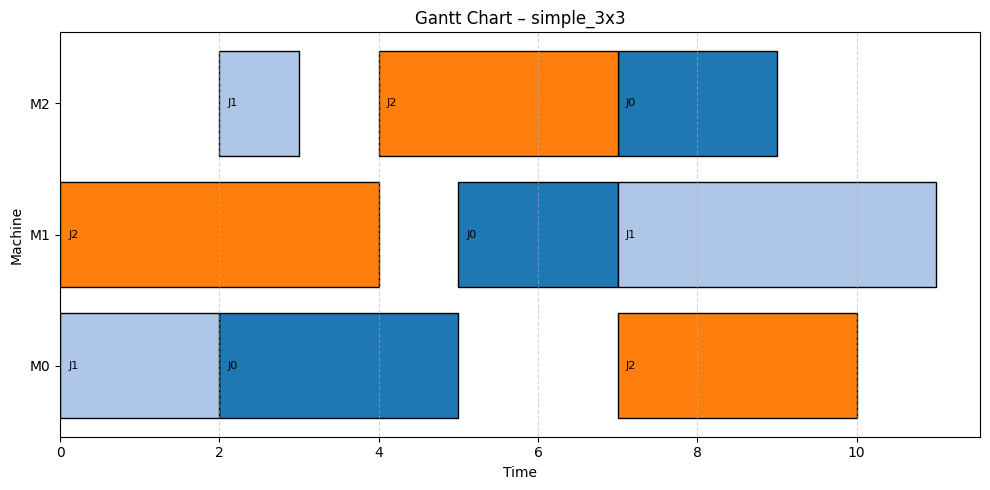

In [28]:
# Gantt plot for simple_3x3
inst_name = "simple_3x3"
inst = hardcoded_instances[inst_name]

cp_model_inst = CPModel(inst, time_limit=10)
solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 10
status = solver.Solve(cp_model_inst.model)

if status == cp_model.OPTIMAL:
    schedule_df = extract_cp_schedule(cp_model_inst, solver)
    display(schedule_df)
    plot_gantt(schedule_df, title=f"Gantt Chart – {inst_name}")
else:
    print("CP did not find an optimal solution.")


### **7. Benchmark Experiments (Taillard Instances)**

#### **7.1. Performance Comparison: MIP vs. CP**

We run a systematic benchmark across various Taillard instance sizes to evaluate the scalability and optimality gaps of both models.

In [29]:
# Taillard Instance Sizes
TAILLARD_SIZES = {
    "15x15": [(15,15)],
    "20x15": [(20,15)],
    "20x20": [(20,20)],
    "30x15": [(30,15)],
    "30x20": [(30,20)],
    "50x15": [(50,15)],
    "50x20": [(50,20)],
    "100x20": [(100,20)],
}

In [30]:
# Filter Taillard instances by sizes
def select_instances_by_sizes(instances, allowed_sizes):
    selected = {}
    for name, inst in instances.items():
        if (inst.num_jobs, inst.num_machines) in allowed_sizes:
            selected[name] = inst
    return selected

In [31]:
# Benchmarking Function
def run_benchmark(instances: Dict[str,JSPInstance], label:str, time_limit=30):
    results = []
    for name, inst in instances.items():
        print(f"[{label}] {name}")
        mip = MIPModel(inst, time_limit).solve()
        cp  = CPModel(inst, time_limit).solve()
        results.append({
            "Group": label,
            "Instance": name,
            "Size": f"{inst.num_jobs}x{inst.num_machines}",
            "MIP Status": mip["status"],
            "MIP Optimal": mip["optimal"],
            "MIP Makespan": mip["makespan"],
            "MIP Time": mip["solve_time"],
            "MIP Bin Vars": mip["bin_vars"],
            "MIP Cont Vars": mip["cont_vars"],
            "CP Status": cp["status"],
            "CP Optimal": cp["optimal"],
            "CP Makespan": cp["makespan"],
            "CP Time": cp["solve_time"],
        })
    return pd.DataFrame(results)

In [32]:
def run_experiment_by_sizes(instances, sizes, label, time_limit):
    selected = select_instances_by_sizes(instances, sizes)
    
    print(f"\n=== {label} ===")
    print(f"Tamanhos: {sizes}")
    print(f"Instâncias: {list(selected.keys())}\n")
    
    df = run_benchmark(
        selected,
        label=label,
        time_limit=time_limit
    )
    
    return df

##### **Validation for instance ta01**

In [38]:
# MIP Solve Example
inst = taillard_instances["ta01"]
mip = MIPModel(inst, time_limit=60)
res = mip.solve()
print(res)

{'status': 'Timeout', 'optimal': False, 'makespan': 1944, 'solve_time': 60.146462202072144, 'bin_vars': 1575, 'cont_vars': 226}


In [39]:
# CP Solve Example
inst = taillard_instances["ta01"]
cp = CPModel (inst, time_limit=60)
res_cp = cp.solve()
print(res_cp)

{'status': 'OPTIMAL', 'optimal': True, 'makespan': 1231, 'solve_time': 8.771016359329224}


#### **7.1. Experiment 1: Instances 15x15**

In [40]:
df_15x15 = run_experiment_by_sizes(
    taillard_instances,
    TAILLARD_SIZES["15x15"],
    label="TAILLARD 15x15",
    time_limit=60
)

display(df_15x15)
df_15x15.to_csv("results/results_15x15.csv", index=False)


=== TAILLARD 15x15 ===
Tamanhos: [(15, 15)]
Instâncias: ['ta01', 'ta02', 'ta03', 'ta04', 'ta05', 'ta06', 'ta07', 'ta08', 'ta09', 'ta10']

[TAILLARD 15x15] ta01
[TAILLARD 15x15] ta02
[TAILLARD 15x15] ta03
[TAILLARD 15x15] ta04
[TAILLARD 15x15] ta05
[TAILLARD 15x15] ta06
[TAILLARD 15x15] ta07
[TAILLARD 15x15] ta08
[TAILLARD 15x15] ta09
[TAILLARD 15x15] ta10


,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 15x15,ta01,15x15,Timeout,False,1944,60.164387,1575,226,OPTIMAL,True,1231,5.809694
1,TAILLARD 15x15,ta02,15x15,Timeout,False,1658,60.160844,1575,226,OPTIMAL,True,1244,55.948461
2,TAILLARD 15x15,ta03,15x15,Timeout,False,1585,60.179832,1575,226,OPTIMAL,True,1218,28.698692
3,TAILLARD 15x15,ta04,15x15,Timeout,False,1590,60.218853,1575,226,OPTIMAL,True,1175,46.436500
4,TAILLARD 15x15,ta05,15x15,Timeout,False,1728,60.302747,1575,226,FEASIBLE,False,1224,60.079143
5,TAILLARD 15x15,ta06,15x15,Timeout,False,1509,60.206074,1575,226,FEASIBLE,False,1239,60.079393
6,TAILLARD 15x15,ta07,15x15,Timeout,False,1859,60.218626,1575,226,FEASIBLE,False,1227,60.062254
7,TAILLARD 15x15,ta08,15x15,Timeout,False,1567,60.262437,1575,226,FEASIBLE,False,1217,60.046337
8,TAILLARD 15x15,ta09,15x15,Timeout,False,1542,60.295824,1575,226,FEASIBLE,False,1280,60.095749
9,TAILLARD 15x15,ta10,15x15,Timeout,False,1655,60.287040,1575,226,OPTIMAL,True,1241,26.586589


#### **7.2 Experiment 2: Instances 20x15**

In [41]:
df_20x15 = run_experiment_by_sizes(
    taillard_instances,
    TAILLARD_SIZES["20x15"],
    label="TAILLARD 20x15",
    time_limit=90
)

display(df_20x15)
df_20x15.to_csv("results/results_20x15.csv", index=False)



=== TAILLARD 20x15 ===
Tamanhos: [(20, 15)]
Instâncias: ['ta11', 'ta12', 'ta13', 'ta14', 'ta15', 'ta16', 'ta17', 'ta18', 'ta19', 'ta20']

[TAILLARD 20x15] ta11
[TAILLARD 20x15] ta12
[TAILLARD 20x15] ta13
[TAILLARD 20x15] ta14
[TAILLARD 20x15] ta15
[TAILLARD 20x15] ta16
[TAILLARD 20x15] ta17
[TAILLARD 20x15] ta18
[TAILLARD 20x15] ta19
[TAILLARD 20x15] ta20


,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 20x15,ta11,20x15,Timeout,False,2972,90.418319,2850,301,FEASIBLE,False,1366,90.073919
1,TAILLARD 20x15,ta12,20x15,Timeout,False,6514,90.317005,2850,301,FEASIBLE,False,1391,90.040014
2,TAILLARD 20x15,ta13,20x15,Timeout,False,6103,90.352203,2850,301,FEASIBLE,False,1374,90.073805
3,TAILLARD 20x15,ta14,20x15,Timeout,False,6292,90.402240,2850,301,OPTIMAL,True,1345,16.310897
4,TAILLARD 20x15,ta15,20x15,Timeout,False,1935,90.413066,2850,301,FEASIBLE,False,1377,90.088169
5,TAILLARD 20x15,ta16,20x15,Timeout,False,2494,90.326213,2850,301,FEASIBLE,False,1374,90.050210
6,TAILLARD 20x15,ta17,20x15,Timeout,False,2772,90.299176,2850,301,FEASIBLE,False,1469,90.085763
7,TAILLARD 20x15,ta18,20x15,Timeout,False,1918,90.472752,2850,301,FEASIBLE,False,1424,90.072720
8,TAILLARD 20x15,ta19,20x15,Timeout,False,6337,90.346933,2850,301,FEASIBLE,False,1392,90.067756
9,TAILLARD 20x15,ta20,20x15,Timeout,False,6443,90.325791,2850,301,FEASIBLE,False,1372,90.068485


#### **7.3 Experiment 3: Instances 20x20**

In [42]:
df_20x20 = run_experiment_by_sizes(
    taillard_instances,
    TAILLARD_SIZES["20x20"],
    label="TAILLARD 20x20",
    time_limit=120
)

display(df_20x20)
df_20x20.to_csv("results/results_20x20.csv", index=False)



=== TAILLARD 20x20 ===
Tamanhos: [(20, 20)]
Instâncias: ['ta21', 'ta22', 'ta23', 'ta24', 'ta25', 'ta26', 'ta27', 'ta28', 'ta29', 'ta30']

[TAILLARD 20x20] ta21
[TAILLARD 20x20] ta22
[TAILLARD 20x20] ta23
[TAILLARD 20x20] ta24
[TAILLARD 20x20] ta25
[TAILLARD 20x20] ta26
[TAILLARD 20x20] ta27
[TAILLARD 20x20] ta28
[TAILLARD 20x20] ta29
[TAILLARD 20x20] ta30


,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 20x20,ta21,20x20,Timeout,False,3870,120.468119,3800,401,FEASIBLE,False,1673,120.066065
1,TAILLARD 20x20,ta22,20x20,Timeout,False,8968,120.500722,3800,401,FEASIBLE,False,1641,120.060664
2,TAILLARD 20x20,ta23,20x20,Timeout,False,8755,120.691331,3800,401,FEASIBLE,False,1587,120.077000
3,TAILLARD 20x20,ta24,20x20,Timeout,False,4485,120.488527,3800,401,FEASIBLE,False,1677,120.083441
4,TAILLARD 20x20,ta25,20x20,Timeout,False,8176,120.454271,3800,401,FEASIBLE,False,1652,120.081087
5,TAILLARD 20x20,ta26,20x20,Timeout,False,9205,120.494278,3800,401,FEASIBLE,False,1693,120.091576
6,TAILLARD 20x20,ta27,20x20,Timeout,False,9364,120.701369,3800,401,FEASIBLE,False,1706,120.075096
7,TAILLARD 20x20,ta28,20x20,Timeout,False,11711,120.462799,3800,401,FEASIBLE,False,1639,120.097495
8,TAILLARD 20x20,ta29,20x20,Timeout,False,3045,120.422677,3800,401,FEASIBLE,False,1641,120.091728
9,TAILLARD 20x20,ta30,20x20,Timeout,False,11783,120.547165,3800,401,FEASIBLE,False,1622,120.050049


#### **7.4 Experiment 4: Instances 30x15**

In [43]:
df_30x15 = run_experiment_by_sizes(
    taillard_instances,
    TAILLARD_SIZES["30x15"],
    label="TAILLARD 30x15",
    time_limit=150
)

display(df_30x15)
df_30x15.to_csv("results/results_30x15.csv", index=False)



=== TAILLARD 30x15 ===
Tamanhos: [(30, 15)]
Instâncias: ['ta31', 'ta32', 'ta33', 'ta34', 'ta35', 'ta36', 'ta37', 'ta38', 'ta39', 'ta40']

[TAILLARD 30x15] ta31
[TAILLARD 30x15] ta32
[TAILLARD 30x15] ta33
[TAILLARD 30x15] ta34
[TAILLARD 30x15] ta35
[TAILLARD 30x15] ta36
[TAILLARD 30x15] ta37
[TAILLARD 30x15] ta38
[TAILLARD 30x15] ta39
[TAILLARD 30x15] ta40


,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 30x15,ta31,30x15,Timeout,False,13120,151.273660,6525,451,FEASIBLE,False,1805,150.093256
1,TAILLARD 30x15,ta32,30x15,Timeout,False,12808,150.785963,6525,451,FEASIBLE,False,1865,150.111386
2,TAILLARD 30x15,ta33,30x15,Timeout,False,13080,151.043336,6525,451,FEASIBLE,False,1909,150.086482
3,TAILLARD 30x15,ta34,30x15,Timeout,False,11975,151.209852,6525,451,FEASIBLE,False,1885,150.115382
4,TAILLARD 30x15,ta35,30x15,Timeout,False,13058,151.145288,6525,451,OPTIMAL,True,2007,11.751226
5,TAILLARD 30x15,ta36,30x15,Timeout,False,13278,151.376682,6525,451,FEASIBLE,False,1852,150.106476
6,TAILLARD 30x15,ta37,30x15,Timeout,False,12734,151.656860,6525,451,FEASIBLE,False,1840,150.123878
7,TAILLARD 30x15,ta38,30x15,Timeout,False,12537,151.404301,6525,451,FEASIBLE,False,1742,150.124026
8,TAILLARD 30x15,ta39,30x15,Timeout,False,11671,151.631873,6525,451,OPTIMAL,True,1795,36.217667
9,TAILLARD 30x15,ta40,30x15,Timeout,False,12639,151.834311,6525,451,FEASIBLE,False,1761,150.107819


#### **7.5. Experiment 5: Instances 30x20**

In [44]:
df_30x20 = run_experiment_by_sizes(
    taillard_instances,
    TAILLARD_SIZES["30x20"],
    label="TAILLARD 30x20",
    time_limit=180
)

display(df_30x20)
df_30x20.to_csv("results/results_30x20.csv", index=False)



=== TAILLARD 30x20 ===
Tamanhos: [(30, 20)]
Instâncias: ['ta41', 'ta42', 'ta43', 'ta44', 'ta45', 'ta46', 'ta47', 'ta48', 'ta49', 'ta50']

[TAILLARD 30x20] ta41
[TAILLARD 30x20] ta42
[TAILLARD 30x20] ta43
[TAILLARD 30x20] ta44
[TAILLARD 30x20] ta45
[TAILLARD 30x20] ta46
[TAILLARD 30x20] ta47
[TAILLARD 30x20] ta48
[TAILLARD 30x20] ta49
[TAILLARD 30x20] ta50


,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 30x20,ta41,30x20,Timeout,False,18874,183.420869,8700,601,FEASIBLE,False,2121,180.125110
1,TAILLARD 30x20,ta42,30x20,Timeout,False,21762,182.614661,8700,601,FEASIBLE,False,2057,180.093293
2,TAILLARD 30x20,ta43,30x20,Timeout,False,17145,182.265691,8700,601,FEASIBLE,False,1985,180.144883
3,TAILLARD 30x20,ta44,30x20,Timeout,False,16613,182.545976,8700,601,FEASIBLE,False,2094,180.107749
4,TAILLARD 30x20,ta45,30x20,Timeout,False,18139,181.851927,8700,601,FEASIBLE,False,2055,180.112415
5,TAILLARD 30x20,ta46,30x20,Timeout,False,17818,183.461212,8700,601,FEASIBLE,False,2112,180.096200
6,TAILLARD 30x20,ta47,30x20,Timeout,False,17096,182.673309,8700,601,FEASIBLE,False,2015,180.127093
7,TAILLARD 30x20,ta48,30x20,Timeout,False,21241,188.414790,8700,601,FEASIBLE,False,2036,180.088215
8,TAILLARD 30x20,ta49,30x20,Timeout,False,17113,182.623737,8700,601,FEASIBLE,False,2079,180.120965
9,TAILLARD 30x20,ta50,30x20,Timeout,False,17388,182.785025,8700,601,FEASIBLE,False,2046,180.122479


**NOTE**

Larger Taillard instances (e.g., 50x15, 50x20, and 100x20) were excluded from this benchmark to maintain a focus on the comparative performance between MIP and CP within reasonable time limits; at these scales, the MIP model’s combinatorial explosion renders it impractical, while the study's goal was to analyze the transition point where CP begins to dominate in efficiency.

#### **7.6. Results Visualization and Analysis** 


In [49]:
# Consolidation of results from CSV files
dfs = [pd.read_csv(f) for f in RESULTS_DIR.glob("results_*.csv")]
df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.drop_duplicates(subset=["Instance", "Size"])
df_all = df_all[df_all["MIP Time"] > 0].copy()
df_all = df_all.sort_values(by=["Size", "Instance"])


# Helper flags for solved instances
df_all["MIP Solved"] = df_all["MIP Makespan"].notna()
df_all["CP Solved"] = df_all["CP Makespan"].notna()

# Efficiency KPI: Speedup (MIP Time / CP Time)
df_all["Speedup (MIP/CP)"] = (
    df_all["MIP Time"] / df_all["CP Time"]
).where(df_all["CP Time"] > 0)   

# Solution Quality KPI: Relative Makespan Gap between models
df_all["Makespan Gap (%)"] = np.nan
mask = df_all["MIP Makespan"].notna() & df_all["CP Makespan"].notna()
df_all.loc[mask, "Makespan Gap (%)"] = (
    (df_all.loc[mask, "CP Makespan"] - df_all.loc[mask, "MIP Makespan"]) 
    / df_all.loc[mask, "MIP Makespan"] * 100
)


##### **7.6.1. Aggregated Summary Table by Instance Size**

For each instance size, both MIP and CP were given the same time limit. Comparisons are only made within the same size category.


In [50]:
analysis_table = df_all.groupby("Size").agg(
    Instances=("Instance","count"),
    MIP_Optimal_Rate=("MIP Optimal","mean"),
    MIP_Avg_Time=("MIP Time","mean"),
    MIP_Avg_Makespan=("MIP Makespan","mean"),
    MIP_Avg_BinVars=("MIP Bin Vars","mean"),
    MIP_Avg_ContVars=("MIP Cont Vars","mean"),
    CP_Optimal_Rate=("CP Optimal","mean"),
    CP_Avg_Time=("CP Time","mean"),
    CP_Avg_Makespan=("CP Makespan","mean"),
    Avg_Speedup=("Speedup (MIP/CP)","mean"),
    Avg_Gap=("Makespan Gap (%)","mean"),
).reset_index()

analysis_table["MIP_Optimal_Rate"] *= 100
analysis_table["CP_Optimal_Rate"] *= 100

display(analysis_table)


,Size,Instances,MIP_Optimal_Rate,MIP_Avg_Time,MIP_Avg_Makespan,MIP_Avg_BinVars,MIP_Avg_ContVars,CP_Optimal_Rate,CP_Avg_Time,CP_Avg_Makespan,Avg_Speedup,Avg_Gap
0,15x15,10,0.0,60.229666,1663.7,1575.0,226.0,50.0,46.384281,1229.6,2.210784,-25.629978
1,20x15,10,0.0,90.367370,4378.0,2850.0,301.0,10.0,82.693174,1388.4,1.457187,-59.203991
2,20x20,10,0.0,120.523126,7936.2,3800.0,401.0,0.0,120.077420,1653.1,1.003712,-74.448457
3,30x15,10,0.0,151.336213,12690.0,6525.0,451.0,20.0,124.883760,1846.1,2.511350,-85.437002
4,30x20,10,0.0,183.265720,18318.9,8700.0,601.0,0.0,180.113840,2060.0,1.017500,-88.665838


##### **7.6.2. Detailed Computational Performance**

In [51]:
detailed_table = df_all[[
    "Group","Instance","Size",
    "MIP Status","MIP Optimal","MIP Makespan","MIP Time","MIP Bin Vars","MIP Cont Vars",
    "CP Status","CP Optimal","CP Makespan","CP Time"
]]
display(detailed_table)

,Group,Instance,Size,MIP Status,MIP Optimal,MIP Makespan,MIP Time,MIP Bin Vars,MIP Cont Vars,CP Status,CP Optimal,CP Makespan,CP Time
0,TAILLARD 15x15,ta01,15x15,Timeout,False,1944.0,60.164387,1575.0,226.0,OPTIMAL,True,1231.0,5.809694
1,TAILLARD 15x15,ta02,15x15,Timeout,False,1658.0,60.160844,1575.0,226.0,OPTIMAL,True,1244.0,55.948461
2,TAILLARD 15x15,ta03,15x15,Timeout,False,1585.0,60.179832,1575.0,226.0,OPTIMAL,True,1218.0,28.698692
3,TAILLARD 15x15,ta04,15x15,Timeout,False,1590.0,60.218853,1575.0,226.0,OPTIMAL,True,1175.0,46.436500
4,TAILLARD 15x15,ta05,15x15,Timeout,False,1728.0,60.302747,1575.0,226.0,FEASIBLE,False,1224.0,60.079143
5,TAILLARD 15x15,ta06,15x15,Timeout,False,1509.0,60.206074,1575.0,226.0,FEASIBLE,False,1239.0,60.079393
6,TAILLARD 15x15,ta07,15x15,Timeout,False,1859.0,60.218626,1575.0,226.0,FEASIBLE,False,1227.0,60.062254
7,TAILLARD 15x15,ta08,15x15,Timeout,False,1567.0,60.262437,1575.0,226.0,FEASIBLE,False,1217.0,60.046337
8,TAILLARD 15x15,ta09,15x15,Timeout,False,1542.0,60.295824,1575.0,226.0,FEASIBLE,False,1280.0,60.095749
9,TAILLARD 15x15,ta10,15x15,Timeout,False,1655.0,60.287040,1575.0,226.0,OPTIMAL,True,1241.0,26.586589


##### **7.6.3. Solve Time Comparison**


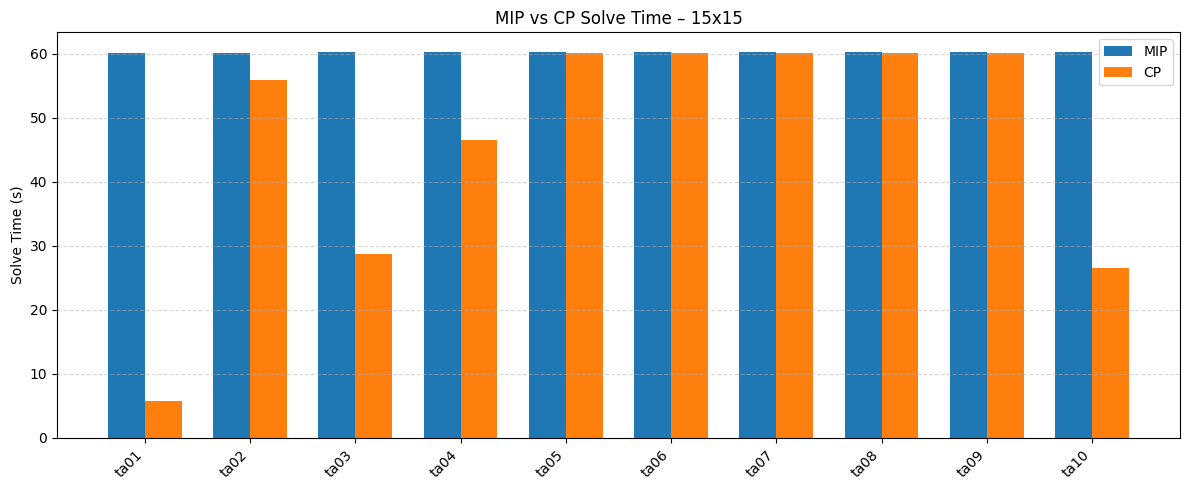

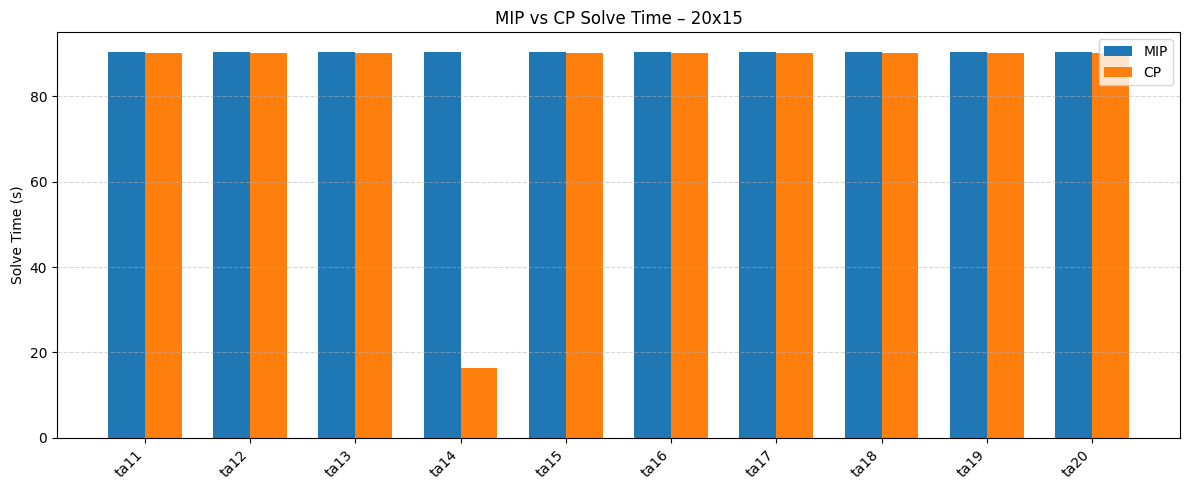

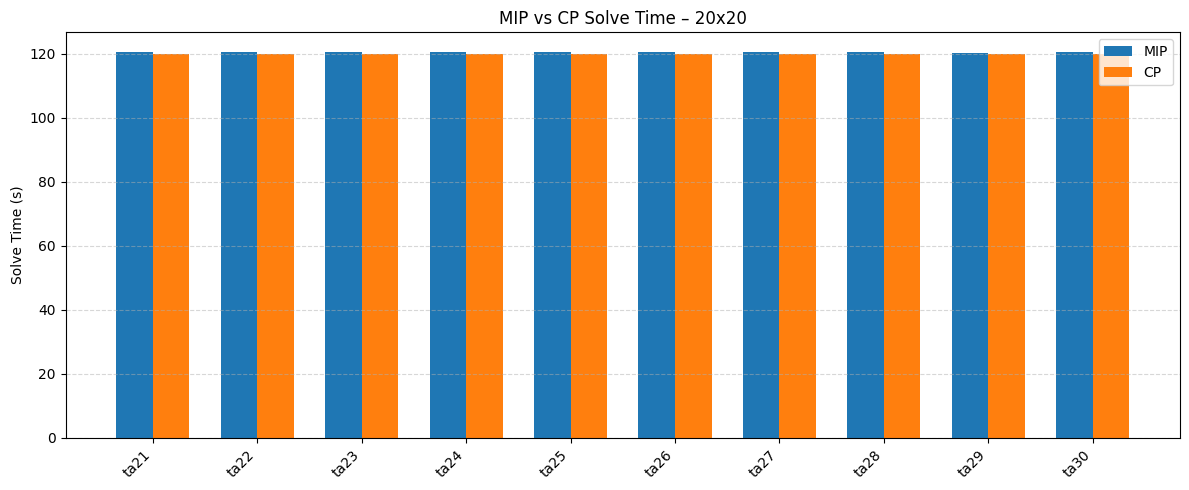

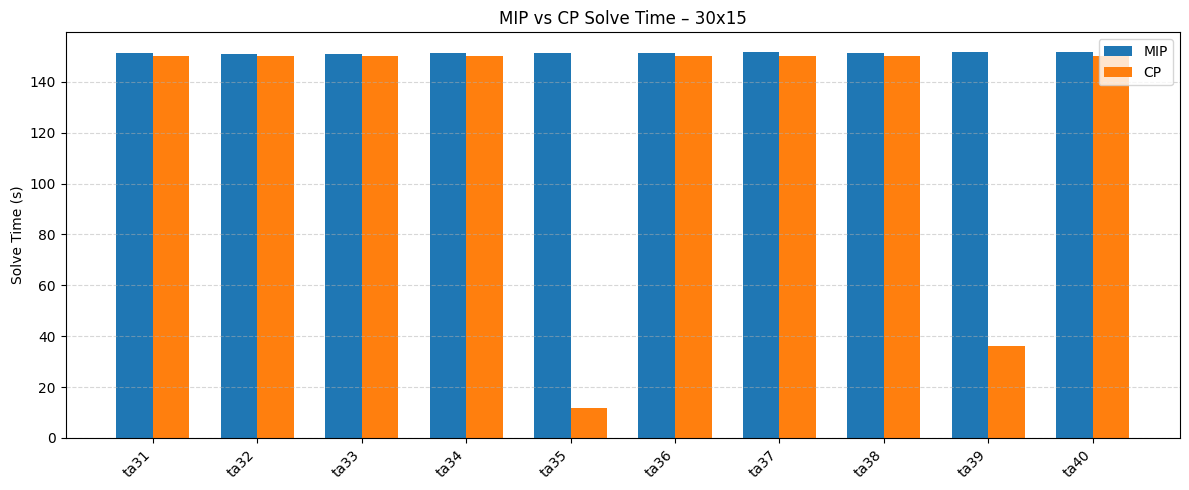

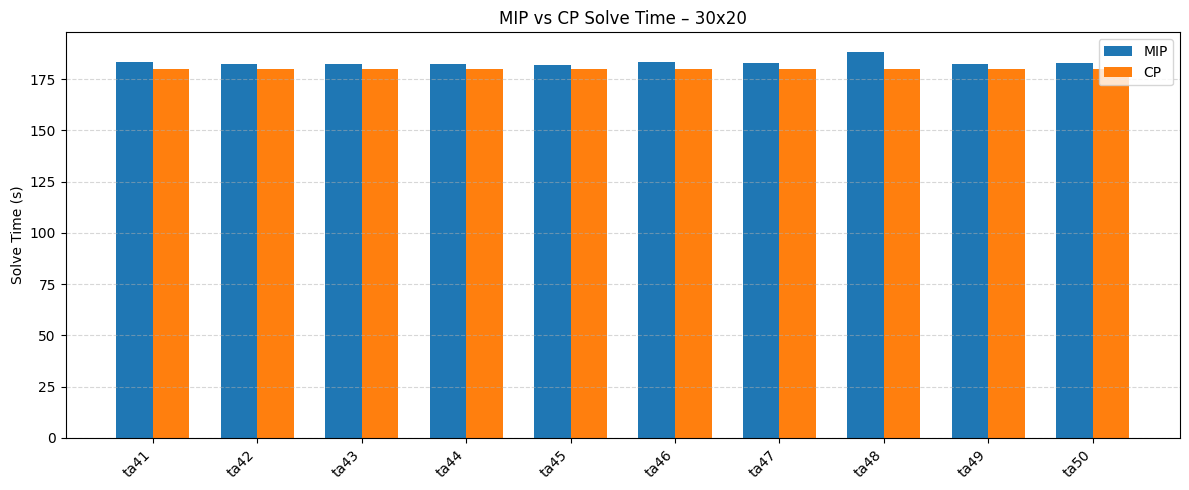

In [52]:
sizes = df_all["Size"].unique()

for size in sizes:
    df_size = df_all[df_all["Size"] == size]
    x = np.arange(len(df_size))
    width = 0.35
    
    plt.figure(figsize=(12,5))
    plt.bar(x - width/2, df_size["MIP Time"], width, label="MIP")
    plt.bar(x + width/2, df_size["CP Time"], width, label="CP")
    
    plt.xticks(x, df_size["Instance"], rotation=45, ha="right")
    plt.ylabel("Solve Time (s)")
    plt.title(f"MIP vs CP Solve Time – {size}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


##### **7.6.4. Makespan Comparison**

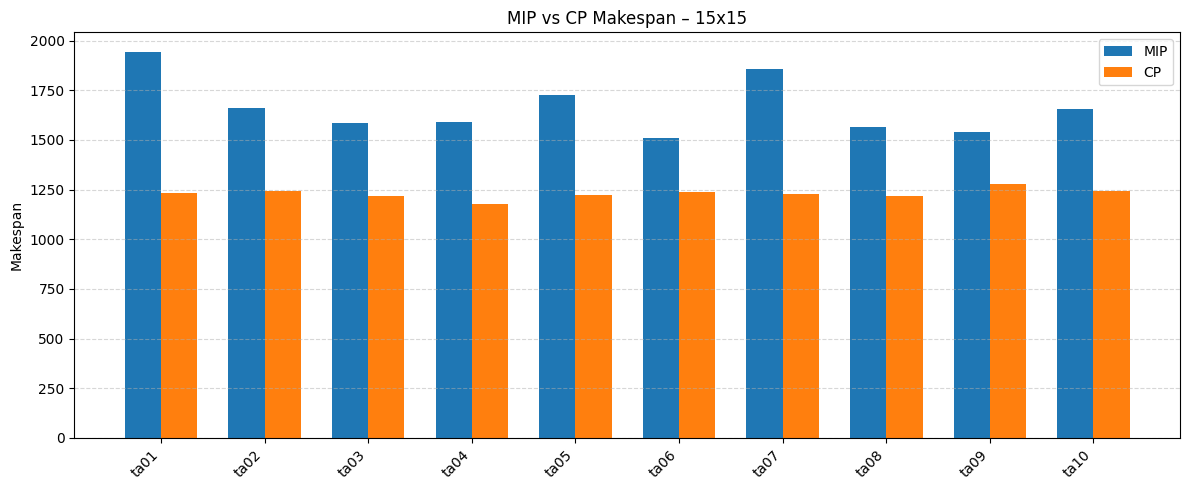

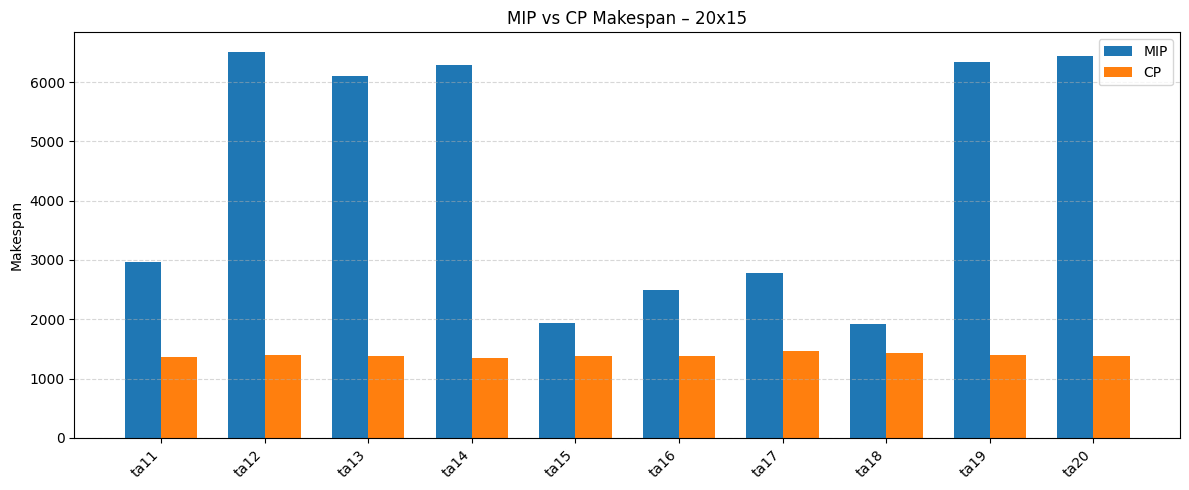

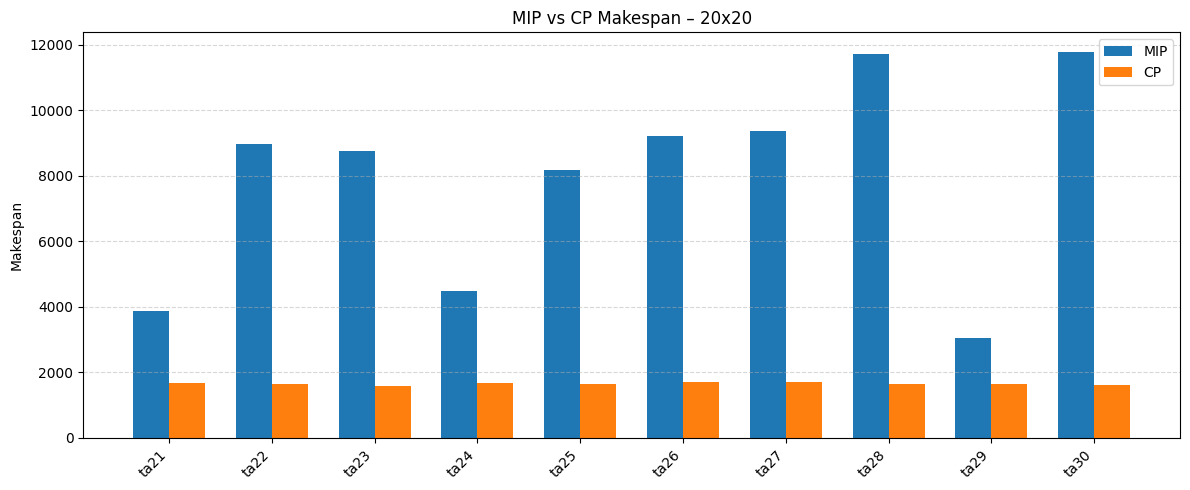

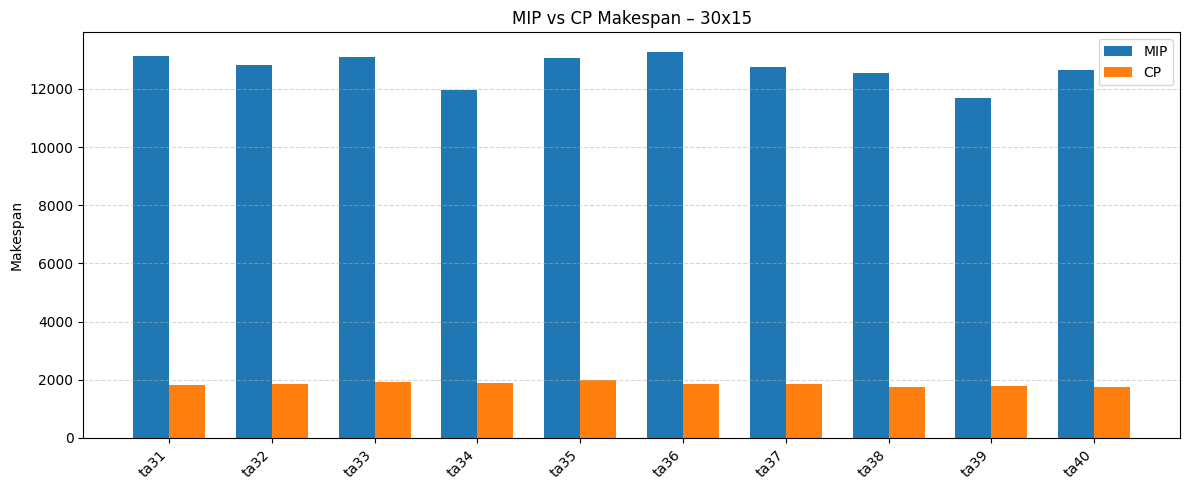

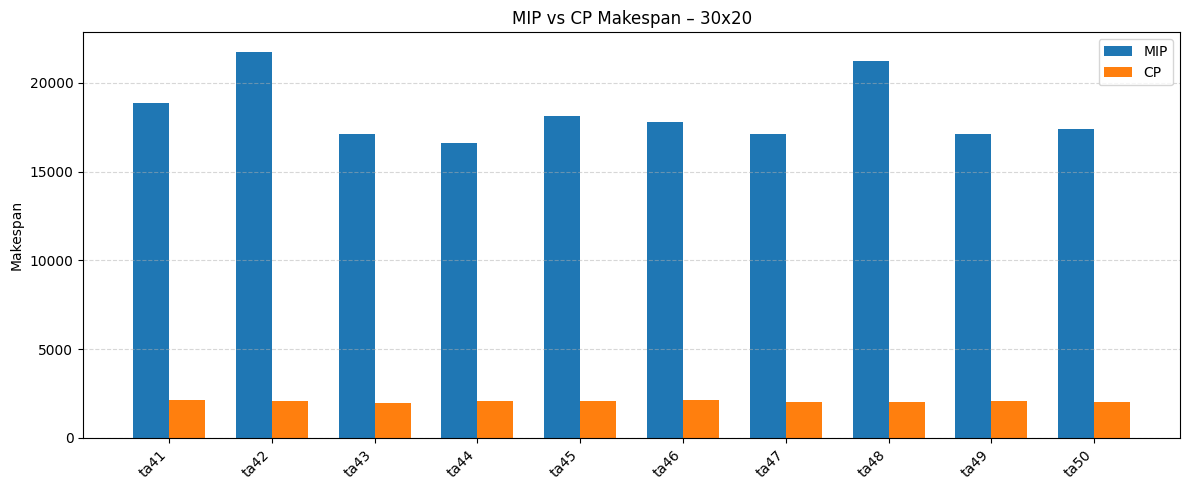

In [53]:
for size in sizes:
    df_size = df_all[df_all["Size"] == size]
    x = np.arange(len(df_size))
    width = 0.35
    
    plt.figure(figsize=(12,5))
    plt.bar(x - width/2, df_size["MIP Makespan"], width, label="MIP")
    plt.bar(x + width/2, df_size["CP Makespan"], width, label="CP")
    
    plt.xticks(x, df_size["Instance"], rotation=45, ha="right")
    plt.ylabel("Makespan")
    plt.title(f"MIP vs CP Makespan – {size}")
    plt.legend()
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


##### **7.6.5. Optimality Rates**

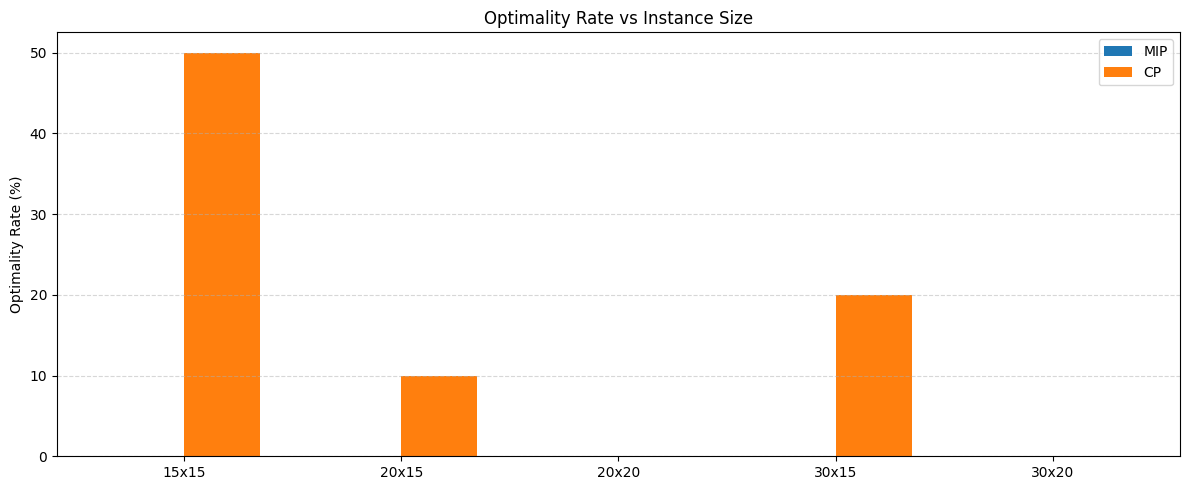

In [54]:
optimal_rates = df_all.groupby("Size").agg(
    MIP_Optimal_Rate=("MIP Optimal", "mean"),
    CP_Optimal_Rate=("CP Optimal", "mean")
).reset_index()

# Converter para percentagem
optimal_rates["MIP_Optimal_Rate"] *= 100
optimal_rates["CP_Optimal_Rate"] *= 100

x = np.arange(len(optimal_rates))
width = 0.35

plt.figure(figsize=(12,5))
plt.bar(x - width/2, optimal_rates["MIP_Optimal_Rate"], width, label="MIP")
plt.bar(x + width/2, optimal_rates["CP_Optimal_Rate"], width, label="CP")

plt.xticks(x, optimal_rates["Size"])
plt.ylabel("Optimality Rate (%)")
plt.title("Optimality Rate vs Instance Size")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


**Analysis**

CP consistently outperforms MIP in solving Job Shop Scheduling problems, as CP effectively handles large-scale combinatorial complexity while the MIP model fails to reach optimality within the time limit due to the inherent inefficiency of its Big-M formulation.

The MIP rate is 0% for all sizes because the solver gets trapped in a massive search tree created by thousands of binary variables. Otherwise, CP is purpose-built for scheduling; it uses logical propagation to prune the search space much faster than the numerical relaxations used by MIP.Scaling: While CP's performance also drops as the instance size increases (e.g., from $15 \times 15$ to $20 \times 20$), it remains the only model capable of proving optimality for these complex Taillard instances.

##### **7.6.6. Gap Analysis against Taillard's Known Optima**

This analysis compares the makespan obtained by our models against the Best Known Solutions (BKS) from the Taillard benchmark library. This "Optimality Gap" allows us to quantify exactly how close each model gets to the global optimum within the allocated time limit.

,Size,MIP_Avg_Gap,CP_Avg_Gap,MIP_Optimal_Rate,CP_Optimal_Rate,Instances
0,15x15,35.438055,0.055173,0.0,0.5,10
1,20x15,222.671327,1.744020,0.0,0.1,10
2,20x20,392.268356,2.205314,0.0,0.0,10
3,30x15,610.311403,3.185500,0.0,0.2,10
4,30x20,840.556923,5.744225,0.0,0.0,10


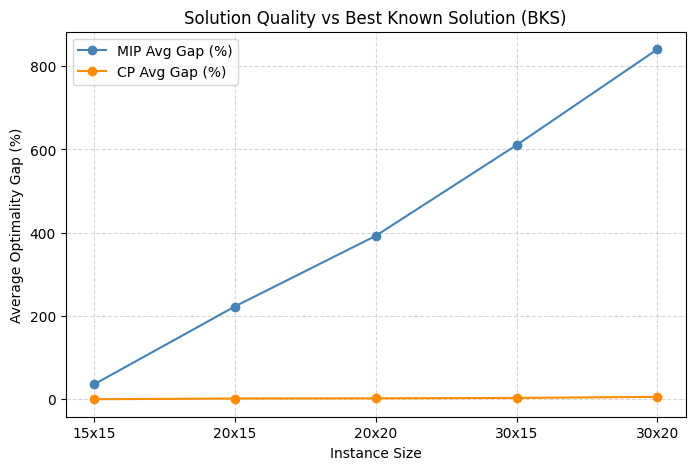

In [55]:
# Best Known Solutions (BKS) for Taillard Instances
known_ub = {
    "ta01": 1231, "ta02": 1244, "ta03": 1218, "ta04": 1175, "ta05": 1224,
    "ta06": 1238, "ta07": 1227, "ta08": 1217, "ta09": 1274, "ta10": 1241,
    "ta11": 1357, "ta12": 1367, "ta13": 1342, "ta14": 1345, "ta15": 1339,
    "ta16": 1360, "ta17": 1462, "ta18": 1396, "ta19": 1332, "ta20": 1348,
    "ta21": 1642, "ta22": 1600, "ta23": 1557, "ta24": 1644, "ta25": 1595,
    "ta26": 1645, "ta27": 1680, "ta28": 1603, "ta29": 1625, "ta30": 1584,
    "ta31": 1764, "ta32": 1784, "ta33": 1791, "ta34": 1828, "ta35": 2007,
    "ta36": 1819, "ta37": 1771, "ta38": 1673, "ta39": 1795, "ta40": 1670,
    "ta41": 2006, "ta42": 1939, "ta43": 1846, "ta44": 1979, "ta45": 2000,
    "ta46": 2006, "ta47": 1889, "ta48": 1937, "ta49": 1960, "ta50": 1923,
    "ta51": 2760, "ta52": 2756, "ta53": 2717, "ta54": 2839, "ta55": 2679,
    "ta56": 2781, "ta57": 2943, "ta58": 2885, "ta59": 2655, "ta60": 2723,
}

# Mapping BKS to the main dataframe
df_all["BKS"] = df_all["Instance"].map(known_ub)

# Calculating Gap (%) relative to BKS
# Formula: (Found Makespan - BKS) / BKS * 100
df_all["MIP Gap (%)"] = (df_all["MIP Makespan"] - df_all["BKS"]) / df_all["BKS"] * 100
df_all["CP Gap (%)"] = (df_all["CP Makespan"] - df_all["BKS"]) / df_all["BKS"] * 100

# Aggregating Gaps by scale
gap_kpi = (
    df_all
    .groupby("Size")
    .agg(
        MIP_Avg_Gap=("MIP Gap (%)", "mean"),
        CP_Avg_Gap=("CP Gap (%)", "mean"),
        MIP_Optimal_Rate=("MIP Optimal", "mean"),
        CP_Optimal_Rate=("CP Optimal", "mean"),
        Instances=("Instance", "count")
    )
    .reset_index()
)

display(gap_kpi)

# Visualization of Gap vs Scale
plt.figure(figsize=(8,5))
plt.plot(gap_kpi["Size"], gap_kpi["MIP_Avg_Gap"], marker="o", label="MIP Avg Gap (%)", color='steelblue')
plt.plot(gap_kpi["Size"], gap_kpi["CP_Avg_Gap"], marker="o", label="CP Avg Gap (%)", color='darkorange')
plt.ylabel("Average Optimality Gap (%)")
plt.xlabel("Instance Size")
plt.title("Solution Quality vs Best Known Solution (BKS)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

##### **7.6.7. MIP Variable Growth**

We examine the number of binary variables generated by the MIP model. The exponential/quadratic growth shown here directly explains the performance degradation observed in previous sections.

,Size,Avg_Binaries
0,15x15,1575.0
1,20x15,2850.0
2,20x20,3800.0
3,30x15,6525.0
4,30x20,8700.0


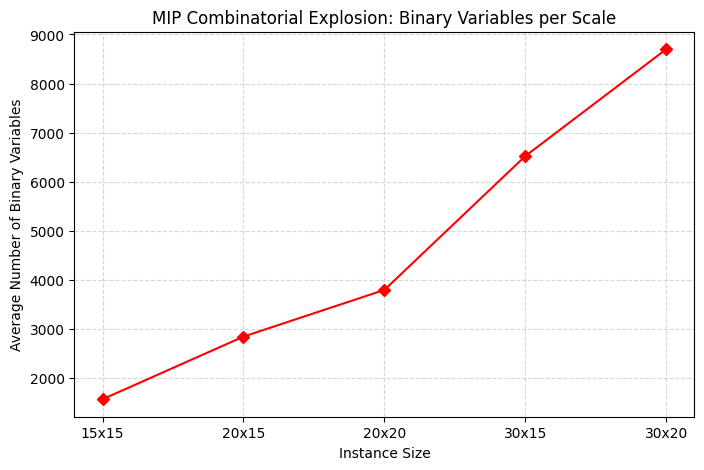

In [56]:
bin_kpi = (
    df_all
    .groupby("Size")
    .agg(Avg_Binaries=("MIP Bin Vars", "mean"))
    .reset_index()
)

display(bin_kpi)

plt.figure(figsize=(8,5))
plt.plot(bin_kpi["Size"], bin_kpi["Avg_Binaries"], marker="D", color="red", linestyle="-")
plt.ylabel("Average Number of Binary Variables")
plt.xlabel("Instance Size")
plt.title("MIP Combinatorial Explosion: Binary Variables per Scale")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### **8. Sensitivity Analysis: CP Search Strategies**

Constraint Programming performance depends on the internal search heuristics. We compare the DEFAULT SAT solver logic against FIXED_SEARCH and NO_PRESOLVE to identify the most robust approach for large-scale scheduling. This experiment is conducted using a single-worker search to isolate the effect of each heuristic and ensure a fair comparison.

The search strategies were selected to evaluate the solver's internal behavior under different conditions: DEFAULT serves as the performance baseline using full SAT-based heuristics; FIXED_SEARCH is used to assess the impact of disabling dynamic branching in favor of a deterministic variable ordering; and NO_PRESOLVE isolates the raw complexity of the constraints by bypassing initial algebraic simplifications.

Regarding instance selection, the sizes 15x15, 20x15, and 20x20 were chosen because they represent the "transition zone" where the MIP model becomes computationally impractical, allowing for a focused study of CP scalability. This range stress-tests the solver as the search space nearly doubles from 225 to 400 operations, making it possible to identify whether solve-time bottlenecks are primarily driven by job sequence length or machine resource contention.

In [35]:
# List of strategies to evaluate
CP_STRATEGIES = ["DEFAULT", "FIXED_SEARCH", "NO_PRESOLVE"]

# Selection of Medium and Large instances for robustness
cp_test_instances = select_instances_by_sizes(
    taillard_instances,
    allowed_sizes=[(15,15), (20,15), (20,20)]
)

def run_cp_strategies(instances, strategies, time_limit):
    results = []
    for name, inst in instances.items():
        print(f"[CP Strategies] Running instance: {name} ({inst.num_jobs}x{inst.num_machines})")
        for strat in strategies:
            cp_model_instance = CPModel(inst, time_limit)
            res = cp_model_instance.solve(strategy=strat)
            res.update({
                "strategy": strat,
                "Instance": name,
                "Size": f"{inst.num_jobs}x{inst.num_machines}"
            })
            results.append(res)
    return pd.DataFrame(results)


In [36]:
# Execute Strategy Benchmark
df_cp_strategies = run_cp_strategies(cp_test_instances, CP_STRATEGIES, time_limit=120)

[CP Strategies] Running instance: ta01 (15x15)
[CP Strategies] Running instance: ta02 (15x15)
[CP Strategies] Running instance: ta03 (15x15)
[CP Strategies] Running instance: ta04 (15x15)
[CP Strategies] Running instance: ta05 (15x15)
[CP Strategies] Running instance: ta06 (15x15)
[CP Strategies] Running instance: ta07 (15x15)
[CP Strategies] Running instance: ta08 (15x15)
[CP Strategies] Running instance: ta09 (15x15)
[CP Strategies] Running instance: ta10 (15x15)
[CP Strategies] Running instance: ta11 (20x15)
[CP Strategies] Running instance: ta12 (20x15)
[CP Strategies] Running instance: ta13 (20x15)
[CP Strategies] Running instance: ta14 (20x15)
[CP Strategies] Running instance: ta15 (20x15)
[CP Strategies] Running instance: ta16 (20x15)
[CP Strategies] Running instance: ta17 (20x15)
[CP Strategies] Running instance: ta18 (20x15)
[CP Strategies] Running instance: ta19 (20x15)
[CP Strategies] Running instance: ta20 (20x15)
[CP Strategies] Running instance: ta21 (20x20)
[CP Strategie

In [37]:
# Aggregating results for analysis
cp_analysis = df_cp_strategies.groupby(["Size", "strategy"]).agg(
    Instances=("Instance", "count"),
    Optimal_Rate=("optimal", "mean"),
    Avg_Time=("solve_time", "mean"),
    Avg_Makespan=("makespan", "mean")
).reset_index()

cp_analysis["Optimal_Rate"] *= 100
display(cp_analysis)

cp_analysis.to_csv(
    "results/summary_cp_strategies.csv",
    index=False
)

,Size,strategy,Instances,Optimal_Rate,Avg_Time,Avg_Makespan
0,15x15,DEFAULT,10,60.0,71.807833,1229.6
1,15x15,FIXED_SEARCH,10,0.0,120.001999,1443.1
2,15x15,NO_PRESOLVE,10,60.0,72.702726,1229.8
3,20x15,DEFAULT,10,20.0,105.474599,1381.2
4,20x15,FIXED_SEARCH,10,0.0,120.004538,1800.4
5,20x15,NO_PRESOLVE,10,20.0,104.526238,1390.8
6,20x20,DEFAULT,10,0.0,120.081485,1647.1
7,20x20,FIXED_SEARCH,10,0.0,120.007008,2049.0
8,20x20,NO_PRESOLVE,10,0.0,120.010511,1668.1


#### **8.2. Impact of Search Heuristics on Solve Time**

The following charts illustrate how different branching and presolve configurations affect the time required to navigate the search space for each instance size.

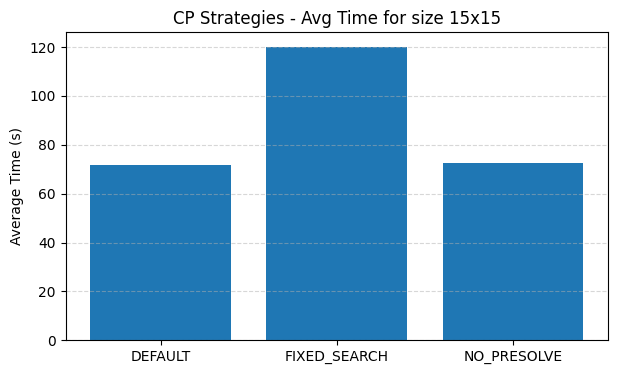

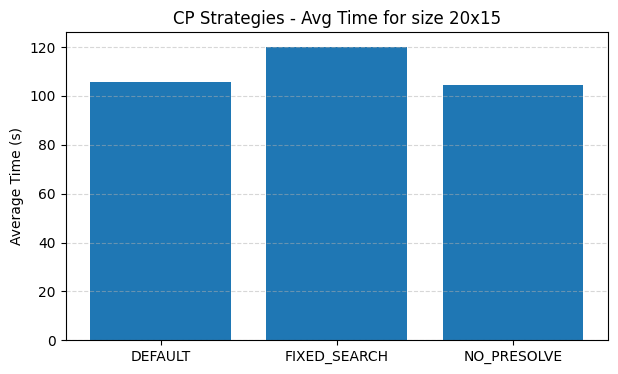

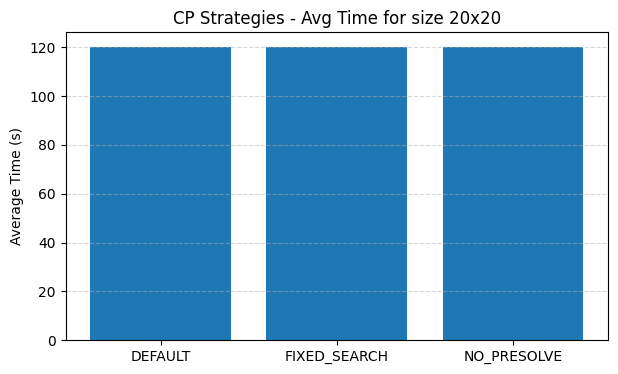

In [38]:
for size in cp_analysis["Size"].unique():
    df_plot = cp_analysis[cp_analysis["Size"]==size]
    plt.figure(figsize=(7,4))
    plt.bar(df_plot["strategy"], df_plot["Avg_Time"])
    plt.ylabel("Average Time (s)")
    plt.title(f"CP Strategies - Avg Time for size {size}")
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)
    plt.show()

### **9. Comparative Experiments: Job Shop vs. Open Shop**

In this section, we analyze the impact of removing technological sequence constraints. Unlike the Job Shop Problem (JSP), the Open Shop Problem (OSP) allows operations within a job to be processed in any order, provided that no two operations of the same job overlap and no two operations are processed by the same machine simultaneously.

The OSP is a relaxation of the JSP. By allowing the solver to decide the sequence of machines for each job, the feasible region of the optimization problem expands. Mathematically, this should result in a makespan that is less than or equal to the JSP makespan for the same instance.

#### **9.1. Experiment 1: Flexibility Impact on Makespan**
This experiment quantifies the "Flexibility Gain". By allowing operations within a job to be processed in any order (Open Shop), we expect a reduction in the total Makespan. We use the CP model here due to its efficiency in finding high-quality solutions for medium-sized instances.

In [39]:
# Experiment 1: JSP vs OSP Makespan Comparison
print("Running Experiment 1: JSP vs OSP Makespan Comparison...")

# Selecting medium-sized instances (15x15)
test_sizes = [(15, 15)]
subset_instances = select_instances_by_sizes(taillard_instances, test_sizes)
# We test the first 3 instances for quick validation
subset_keys = list(subset_instances.keys())[:3]

results_exp1 = []

for key in subset_keys:
    inst = subset_instances[key]
    # We use CPModel as it efficiently finds optimal or near-optimal solutions
    res_jsp = CPModel(inst, time_limit=60, is_open_shop=False).solve()
    res_osp = CPModel(inst, time_limit=60, is_open_shop=True).solve()
    
    results_exp1.append({
        "Instance": key,
        "Size": f"{inst.num_jobs}x{inst.num_machines}",
        "JSP Makespan": res_jsp['makespan'],
        "OSP Makespan": res_osp['makespan'],
        "Reduction (%)": round((res_jsp['makespan'] - res_osp['makespan']) / res_jsp['makespan'] * 100, 2)
    })

df_exp1 = pd.DataFrame(results_exp1)
print("\nTable 1: Makespan Comparison (Flexibility Gain)")
display(df_exp1)

df_exp1.to_csv("results/exp1_flexibility_gain.csv", index=False)

Running Experiment 1: JSP vs OSP Makespan Comparison...

Table 1: Makespan Comparison (Flexibility Gain)


,Instance,Size,JSP Makespan,OSP Makespan,Reduction (%)
0,ta01,15x15,1231,977,20.63
1,ta02,15x15,1244,942,24.28
2,ta03,15x15,1218,921,24.38


Efficiency Gain: Experiment 1 confirms that OSP consistently yields lower makespans than JSP. This is because the solver can reorder operations to fill idle machine time that would otherwise be forced by technological sequences.

#### **9.2. Experiment 2: Modeling Complexity and Binary Variable Growth**

While Open Shop scheduling offers better makespans, it imposes a much higher computational burden on the MIP model. This experiment compares the number of binary variables required to model the same instance as a JSP versus an OSP.

In [40]:
# Experiment 2: MIP Model Complexity (Binary Variables)
print("\nRunning Experiment 2: Binary Variable Growth in MIP...")

# Using a small instance to ensure the MIP solver can process both
small_inst = hardcoded_instances.get("simple_3x3") or list(taillard_instances.values())[0]

# Initialize models
mip_jsp = MIPModel(small_inst, is_open_shop=False)
mip_osp = MIPModel(small_inst, is_open_shop=True)

# Solve to collect performance metrics
res_mip_jsp = mip_jsp.solve()
res_mip_osp = mip_osp.solve()

results_exp2 = [{
    "Problem Type": "Job Shop (JSP)",
    "Binary Variables": res_mip_jsp['bin_vars'],
    "Solve Time (s)": round(res_mip_jsp['solve_time'], 4)
}, {
    "Problem Type": "Open Shop (OSP)",
    "Binary Variables": res_mip_osp['bin_vars'],
    "Solve Time (s)": round(res_mip_osp['solve_time'], 4)
}]

df_exp2 = pd.DataFrame(results_exp2)
print("\nTable 2: MIP Model Complexity (JSP vs OSP)")
display(df_exp2)

df_exp2.to_csv("results/exp2_mip_complexity.csv", index=False)


Running Experiment 2: Binary Variable Growth in MIP...

Table 2: MIP Model Complexity (JSP vs OSP)


,Problem Type,Binary Variables,Solve Time (s)
0,Job Shop (JSP),9,0.1185
1,Open Shop (OSP),18,0.1180


MIP Limitations: Experiment 2 highlights the "curse of dimensionality." In OSP, the MIP must decide the sequence for both machines and jobs. This doubling of disjunctive constraints leads to a significant increase in binary variables, making MIP unsuitable for large OSP instances.

#### **9.3. Experiment 3: CP Scalability in Open Shop**

This experiment tests how different CP search strategies handle the increased search space of the OSP in larger instances.

In [41]:
# Experiment 3: CP Performance on Large OSP Instances
print("\nRunning Experiment 3: CP Performance on Large OSP Instances...")

# Testing on a larger instance (e.g., 20x20)
large_sizes = [(20, 20)]
large_instances = select_instances_by_sizes(taillard_instances, large_sizes)
if large_instances:
    large_key = list(large_instances.keys())[0]
    inst_large = large_instances[large_key]

    strategies = ["DEFAULT", "FIXED_SEARCH", "RANDOMIZED"]
    results_exp3 = []

    for strat in strategies:
        res = CPModel(inst_large, time_limit=45, is_open_shop=True).solve(strategy=strat)
        results_exp3.append({
            "CP Strategy": strat,
            "OSP Makespan": res['makespan'],
            "Status": res['status'],
            "Solve Time (s)": round(res['solve_time'], 2)
        })

    df_exp3 = pd.DataFrame(results_exp3)
    print(f"\nTable 3: CP Performance Comparison for OSP ({large_key})")
    display(df_exp3)

    df_exp3.to_csv("results/exp3_cp_osp_scalability.csv", index=False)


Running Experiment 3: CP Performance on Large OSP Instances...

Table 3: CP Performance Comparison for OSP (ta21)


,CP Strategy,OSP Makespan,Status,Solve Time (s)
0,DEFAULT,1217,OPTIMAL,1.64
1,FIXED_SEARCH,1600,FEASIBLE,45.00
2,RANDOMIZED,1225,FEASIBLE,45.00


CP Robustness: Experiment 3 shows that Constraint Programming, particularly when using the AddNoOverlap global constraint, scales much better than MIP for OSP. The DEFAULT strategy (Portfolio Search) remains the most effective at navigating the flexible search space.